# Tutorial 06 — FastRelax

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/06_fast_relax.ipynb)

Alternate side-chain repacking and minimization under a changing weight schedule. Compare stage endpoints and the accepted result. Complete [packing](04_packing_and_mutation_scan.ipynb) and [minimization](05_minimization_constraints_kinematics.ipynb) first.

The short CPU run does not establish convergence; the ensemble example requires CUDA.


## Setup

In Colab, select **T4 GPU**, then **Run all**. For local execution, follow the [installation guide](../installation.md). Setup installs TMol and downloads the fixtures on first use.

The main example uses a checked-in six-residue 1UBQ slice, one repeat, and a two-stage schedule so it remains practical on CPU. The larger ensemble cell is tagged `gpu-only` and is executed by the GPU CI lane. Both are pedagogical smoke tests rather than production relaxation schedules.


In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol.io import pose_stack_from_biotite
from tmol.kinematics import CartesianMoveMap, FoldForest, MoveMap
from tmol.pack import PackerPalette
from tmol.pose import PoseStackBuilder
from tmol.score import ScoreType, beta2016_score_function
from tmol.score.constraint import create_mainchain_coordinate_constraints

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)
device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)

# Strictly a smoke-test budget shared by every minimizer in this tutorial,
# including the GPU batch. Finite output is not evidence of convergence.
TUTORIAL_MAX_ITER = 10


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def score_components_by_pose(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    weighted_terms = scorer(
        pose_stack.coords, sum_terms=False, apply_weights=True
    )
    score_types = score_function.all_score_types()
    total_scores = weighted_terms.sum(dim=0)
    constraint_index = next(
        (
            index
            for index, score_type in enumerate(score_types)
            if score_type == ScoreType.constraint
        ),
        None,
    )
    constraint_scores = (
        torch.zeros_like(total_scores)
        if constraint_index is None
        else weighted_terms[constraint_index]
    )
    non_constraint_scores = total_scores - constraint_scores
    return [
        {
            "non_constraint_score_units": float(non_constraint_scores[i].detach().cpu()),
            "constraint_score_units": float(constraint_scores[i].detach().cpu()),
            "reported_total_score_units": float(total_scores[i].detach().cpu()),
        }
        for i in range(pose_stack.n_poses)
    ]


def score_components(pose_stack, score_function):
    if pose_stack.n_poses != 1:
        raise ValueError("Use score_components_by_pose() for batched PoseStacks.")
    return score_components_by_pose(pose_stack, score_function)[0]


def common_atom_mask(reference, mobile):
    return torch.isfinite(reference.coords).all(dim=-1) & torch.isfinite(
        mobile.coords
    ).all(dim=-1)


def rms_displacement(reference, mobile):
    """Raw all-atom RMS displacement in the input coordinate frame."""
    mask = common_atom_mask(reference, mobile)
    delta = mobile.coords[mask] - reference.coords[mask]
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def kabsch_aligned_rmsd(reference, mobile):
    """All-atom RMSD after least-squares rigid-body superposition."""
    mask = common_atom_mask(reference, mobile)
    reference_xyz = reference.coords[mask]
    mobile_xyz = mobile.coords[mask]
    reference_centered = reference_xyz - reference_xyz.mean(dim=0)
    mobile_centered = mobile_xyz - mobile_xyz.mean(dim=0)
    covariance = mobile_centered.T @ reference_centered
    u, _, vh = torch.linalg.svd(covariance)
    handedness = torch.sign(torch.det(u @ vh))
    correction = torch.eye(3, device=mobile_xyz.device, dtype=mobile_xyz.dtype)
    correction[-1, -1] = handedness
    rotation = u @ correction @ vh
    delta = mobile_centered @ rotation - reference_centered
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def declared_mainchain_atom_mask(pose_stack):
    """Select atoms named in each residue type's TMol polymer declaration."""
    mask = torch.zeros_like(pose_stack.real_atoms)
    atom_names = []
    seen_atom_names = set()
    for pose_index in range(pose_stack.n_poses):
        for block_index in range(pose_stack.max_n_blocks):
            block_type_index = int(
                pose_stack.block_type_ind64[pose_index, block_index].item()
            )
            if block_type_index < 0:
                continue
            block_type = pose_stack.packed_block_types.active_block_types[
                block_type_index
            ]
            polymer = block_type.properties.polymer
            if polymer is None:
                continue
            atom_offset = int(
                pose_stack.block_coord_offset64[pose_index, block_index].item()
            )
            for atom_name in polymer.mainchain_atoms:
                atom_index = atom_offset + block_type.atom_to_idx[atom_name]
                if bool(pose_stack.real_atoms[pose_index, atom_index]):
                    mask[pose_index, atom_index] = True
                    if atom_name not in seen_atom_names:
                        atom_names.append(atom_name)
                        seen_atom_names.add(atom_name)
    return mask, tuple(atom_names)


def coordinates_equal(first, second):
    if first.coords.shape != second.coords.shape:
        return False
    first_finite = torch.isfinite(first.coords)
    second_finite = torch.isfinite(second.coords)
    return (
        torch.equal(first.block_type_ind64, second.block_type_ind64)
        and torch.equal(first_finite, second_finite)
        and torch.equal(first.coords[first_finite], second.coords[second_finite])
    )

Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository


Environment variable PDB_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository


## Protocol and ramp schedule

`tmol.fast_relax()` alternates side-chain repacking and minimization while increasing the `fa_rep` weight. A `CartesianMoveMap` selects Cartesian coordinates. A `MoveMap`, `FoldForest`, and custom minimizer select kinematic degrees of freedom.

The default protocol uses four stages and two repeats. This tutorial uses two stages, one repeat, and ten minimizer iterations so it runs as a smoke test. Finite output shows that the workflow executes; it does not establish convergence.

Coordinate constraints are attached before relaxation. Each schedule entry scales the starting repulsive and constraint weights, and the final minimization uses full repulsion.


In [3]:
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol" / "tests" / "data" / "cif" / "1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 6)]
setup_diagnostics = StringIO()
try:
    with redirect_stdout(setup_diagnostics), redirect_stderr(setup_diagnostics):
        pose = pose_stack_from_biotite(protein_slice, device, no_optH=True)
        relax_start = create_mainchain_coordinate_constraints(pose)
except Exception:
    print(setup_diagnostics.getvalue())
    raise

score_function = beta2016_score_function(device)
score_function.set_weight(ScoreType.constraint, 1.0)
fa_rep_start = float(score_function.get_weight(ScoreType.fa_ljrep))
constraint_start = float(score_function.get_weight(ScoreType.constraint))
mainchain_mask, restrained_atom_names = declared_mainchain_atom_mask(relax_start)
CONSTRAINT_SIGMA_A = 0.5

palette = PackerPalette()
cartesian_move_map = CartesianMoveMap()
fold_forest = FoldForest.reasonable_fold_forest(relax_start)
tiny_schedule = [
    {"fa_rep_pack_frac": 0.10, "fa_rep_min_frac": 0.20, "cst_frac": 1.0},
    {"fa_rep_pack_frac": 1.00, "fa_rep_min_frac": 1.00, "cst_frac": 0.0},
]

schedule_table = pd.DataFrame(tiny_schedule)
schedule_table["fa_rep_pack_weight"] = (
    schedule_table["fa_rep_pack_frac"] * fa_rep_start
)
schedule_table["fa_rep_min_weight"] = (
    schedule_table["fa_rep_min_frac"] * fa_rep_start
)
schedule_table["constraint_weight"] = schedule_table["cst_frac"] * constraint_start
print("input:", cif_path.name)
print("coordinate-restraint atom names:", ", ".join(restrained_atom_names))
print("coordinate-restraint count:", int(mainchain_mask.sum().item()))
print(f"coordinate-restraint sigma: {CONSTRAINT_SIGMA_A:.1f} Å")
print(f"coordinate-restraint score weight: {constraint_start:.1f}")
print("O is not TMol-declared main chain here and is not constrained.")
show_table(schedule_table)

input: 1UBQ.cif
coordinate-restraint atom names: N, CA, C
coordinate-restraint count: 18
coordinate-restraint sigma: 0.5 Å
coordinate-restraint score weight: 1.0
O is not TMol-declared main chain here and is not constrained.


## Run one repeat

The first stage uses reduced repulsion and the final stage restores full repulsion. The fold forest is passed through the shared protocol API, although the Cartesian minimizer does not use it.

The custom minimizer records the score immediately before and after each short minimization. These values help inspect the workflow, but they are not a convergence test.


In [4]:
def tutorial_cart_min(
    pose_stack, stage_score_function, *, fold_forest, move_map, verbose
):
    del fold_forest
    coord_mask = move_map.coord_mask if isinstance(move_map, CartesianMoveMap) else None
    return tmol.run_cart_min(
        pose_stack,
        stage_score_function,
        coord_mask=coord_mask,
        verbose=verbose,
        optimizer_kwargs={
            "max_iter": TUTORIAL_MAX_ITER,
            "verbose": verbose,
        },
    )


relax_stage_records = []


def recording_cart_min(
    pose_stack, stage_score_function, *, fold_forest, move_map, verbose
):
    constraint_weight = float(
        stage_score_function.get_weight(ScoreType.constraint)
    )
    objective_before = score_components(
        pose_stack, stage_score_function
    )["reported_total_score_units"]
    minimized = tutorial_cart_min(
        pose_stack,
        stage_score_function,
        fold_forest=fold_forest,
        move_map=move_map,
        verbose=verbose,
    )
    objective_after = score_components(
        minimized, stage_score_function
    )["reported_total_score_units"]
    relax_stage_records.append(
        {
            "pose": minimized.clone(),
            "constraint_weight_at_optimization": constraint_weight,
            "objective_before_min_units": objective_before,
            "objective_after_min_units": objective_after,
            "objective_change_during_min_units": objective_after - objective_before,
        }
    )
    return minimized


print(
    f"smoke-test optimizer max_iter: {TUTORIAL_MAX_ITER} "
    "(convergence not assessed)"
)
before_components = score_components(relax_start, score_function)
TUTORIAL_NUM_REPEATS = 1
relaxed = tmol.fast_relax(
    relax_start,
    score_function,
    palette,
    cartesian_move_map,
    fold_forest,
    num_repeats=TUTORIAL_NUM_REPEATS,
    schedule=tiny_schedule,
    ramp_constraints=True,
    min_fn=recording_cart_min,
    verbose=False,
)
assert torch.isfinite(relaxed.coords[relaxed.real_atoms]).all()
after_components = score_components(relaxed, score_function)

if coordinates_equal(relaxed, relax_start):
    accepted_from = "input"
else:
    accepted_from = "unresolved (not an exact recorded repeat endpoint)"
    for repeat_index in range(TUTORIAL_NUM_REPEATS):
        record_index = (repeat_index + 1) * len(tiny_schedule) - 1
        if coordinates_equal(relaxed, relax_stage_records[record_index]["pose"]):
            accepted_from = (
                f"repeat {repeat_index + 1} endpoint "
                f"(stage {record_index + 1})"
            )
            break

score_frame = pd.DataFrame(
    [
        {
            "structure": "before",
            "accepted_from": "not applicable",
            **before_components,
        },
        {
            "structure": "accepted final",
            "accepted_from": accepted_from,
            **after_components,
        },
    ]
)
for component in (
    "non_constraint_score_units",
    "constraint_score_units",
    "reported_total_score_units",
):
    score_frame[f"{component.removesuffix('_units')}_change_units"] = (
        score_frame[component] - before_components[component]
    )
score_frame["finite_smoke_test_output"] = np.isfinite(
    score_frame[
        [
            "non_constraint_score_units",
            "constraint_score_units",
            "reported_total_score_units",
        ]
    ]
).all(axis=1)
score_frame["convergence_status"] = "not assessed (10-iteration smoke test)"
print("accepted final source:", accepted_from)
show_table(score_frame)

smoke-test optimizer max_iter: 10 (convergence not assessed)


accepted final source: repeat 1 endpoint (stage 2)


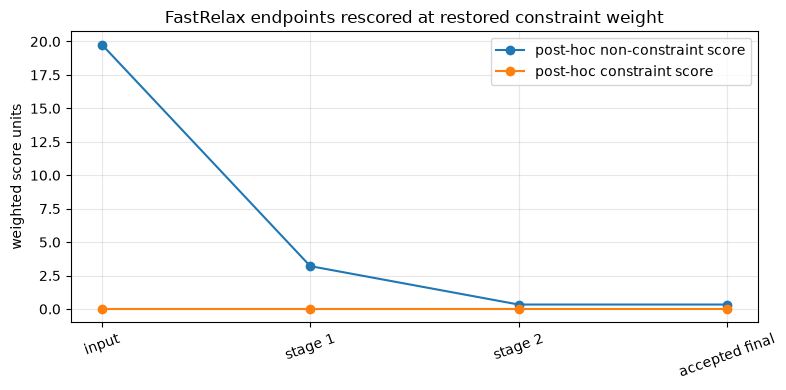

In [5]:
trajectory_structures = {"input": relax_start}
stage_metadata = {
    "input": {
        "constraint_weight_at_optimization": np.nan,
        "objective_before_min_units": np.nan,
        "objective_after_min_units": np.nan,
        "objective_change_during_min_units": np.nan,
    }
}
for stage_index, record in enumerate(relax_stage_records):
    label = f"stage {stage_index + 1}"
    trajectory_structures[label] = record["pose"]
    stage_metadata[label] = record
trajectory_structures["accepted final"] = relaxed
stage_metadata["accepted final"] = {
    "constraint_weight_at_optimization": np.nan,
    "objective_before_min_units": np.nan,
    "objective_after_min_units": np.nan,
    "objective_change_during_min_units": np.nan,
}

# fast_relax restores the starting constraint weight before returning. These
# scores are therefore a common post-hoc decomposition, not each stage's
# historical optimization objective.
posthoc_constraint_weight = float(
    score_function.get_weight(ScoreType.constraint)
)
trajectory_rows = []
trajectory_notes = {}
for frame_index, (label, frame_pose) in enumerate(trajectory_structures.items()):
    components = score_components(frame_pose, score_function)
    metadata = stage_metadata[label]
    raw_displacement = rms_displacement(relax_start, frame_pose)
    aligned_rmsd = kabsch_aligned_rmsd(relax_start, frame_pose)
    trajectory_rows.append(
        {
            "frame": frame_index,
            "label": label,
            "accepted_from": accepted_from if label == "accepted final" else "",
            "constraint_weight_at_optimization": metadata[
                "constraint_weight_at_optimization"
            ],
            "objective_before_min_units": metadata[
                "objective_before_min_units"
            ],
            "objective_after_min_units": metadata[
                "objective_after_min_units"
            ],
            "objective_change_during_min_units": metadata[
                "objective_change_during_min_units"
            ],
            "constraint_weight_for_posthoc_rescore": posthoc_constraint_weight,
            "raw_RMS_displacement_from_input_A": raw_displacement,
            "Kabsch_RMSD_from_input_A": aligned_rmsd,
            **components,
        }
    )
    optimized_weight = metadata["constraint_weight_at_optimization"]
    optimized_text = (
        "not a minimization endpoint"
        if np.isnan(optimized_weight)
        else (
            f"optimized cst weight {optimized_weight:.3f}; min objective change "
            f"{metadata['objective_change_during_min_units']:+.3f}"
        )
    )
    acceptance_text = (
        f"; accepted from {accepted_from}" if label == "accepted final" else ""
    )
    trajectory_notes[label] = (
        f"{optimized_text}; post-hoc non-constraint "
        f"{components['non_constraint_score_units']:.3f}; "
        f"constraint {components['constraint_score_units']:.3f}; "
        f"raw/aligned {raw_displacement:.3f}/{aligned_rmsd:.3f} Å"
        f"{acceptance_text}"
    )
trajectory_frame = pd.DataFrame(trajectory_rows)
show_table(trajectory_frame)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["non_constraint_score_units"],
    marker="o",
    label="post-hoc non-constraint score",
)
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["constraint_score_units"],
    marker="o",
    label="post-hoc constraint score",
)
ax.set(
    xticks=trajectory_frame["frame"],
    xticklabels=trajectory_frame["label"],
    ylabel="weighted score units",
    title="FastRelax endpoints rescored at restored constraint weight",
)
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(
    tmol.switchable_view(
        trajectory_structures,
        notes=trajectory_notes,
    )
)

Check finite scores and geometry. The non-constraint score includes all weighted beta2016 terms except coordinate constraints, including statistical terms. Raw displacement retains frame motion; Kabsch RMSD removes rigid-body motion.

### Stage scores and acceptance

`fast_relax()` restores the starting constraint weight before returning. `score_frame` rescores every structure at these common weights. Historical stage objectives use their own ramp weights and must be compared separately. In particular, the final stage uses `cst_frac=0`; its displayed post-hoc constraint penalty is recalculated at full weight.

The best-pose pool includes the input. After each complete repeat, an endpoint replaces it only if its score is strictly lower. Intermediate stages are not candidates, and a one-repeat run may return the unchanged input. `accepted_from` identifies the selected structure. The switcher shows stage endpoints and the accepted result, not line-search steps or packing trajectories.

**Custom schedules:** the initial best score uses starting weights; repeat acceptance uses the final schedule weights. Here the input restraints are satisfied, which masks the mismatch with the zero-constraint final stage. Rescore input and endpoints at one fixed weight set before comparing custom schedules or initially violated restraints.

The short schedule may not improve the input. Large distortions, missing residues, and NaNs are failures; finite output after ten iterations is not evidence of convergence.

## Minimizer adapters and precision

Custom minimizers receive `min_fn(pose_stack, sfxn, *, fold_forest, move_map, verbose)`. The adapter below calls `tmol.run_kin_min(pose_stack, sfxn, ff, mm, ...)`. Pass a `MoveMap` and `min_fn=kinematic_min_fn` to use it.

Packing requires float32 coordinates. FastRelax converts a float64 pose to float32 for each packing stage, then restores float64 for minimization and output. The example asserts this boundary. Direct `pack_rotamers()` calls should use float32.

`kin_dtype=torch.float64` promotes kinematic DOFs and transformations. Scoring coordinates retain the pose dtype; use a float64 pose for double-precision kinematic minimization.

The adapter is defined but not executed here. [Tutorial 05](05_minimization_constraints_kinematics.ipynb) runs both minimizers directly.


In [6]:
def kinematic_min_fn(
    pose_stack, score_function, *, fold_forest, move_map, verbose
):
    return tmol.run_kin_min(
        pose_stack,
        score_function,
        fold_forest,
        move_map,
        optimizer_kwargs={
            "max_iter": TUTORIAL_MAX_ITER,
            "verbose": verbose,
        },
        verbose=verbose,
        kin_dtype=torch.float64,
    )


kinematic_move_map = MoveMap.from_pose_stack(relax_start)
kinematic_move_map.move_all_named_torsions = True
kinematic_move_map.move_all_jumps = False
kinematic_move_map.move_all_root_jumps = False
print(
    "FastRelax input/output dtype:",
    relax_start.coords.dtype,
    "→",
    relaxed.coords.dtype,
)

# Optional kinematic form using the same public protocol (not run here):
# kin_relaxed = tmol.fast_relax(
#     relax_start,
#     score_function,
#     palette,
#     kinematic_move_map,
#     fold_forest,
#     num_repeats=1,
#     schedule=tiny_schedule,
#     min_fn=kinematic_min_fn,
# )

FastRelax input/output dtype: torch.float32 → torch.float32


## Relax a GPU batch

Batch four perturbed conformations and run the same two-stage schedule, constraint weight, and iteration budget as the single-pose example. Restraints target each member's own starting N/CA/C coordinates; O is excluded.

The table reports matched-weight score changes, displacement, aligned RMSD, and whether acceptance retained the input or repeat endpoint. Benchmark against serial calls on your GPU before choosing a production batch size.

GPU CI executes this `gpu-only` cell; CPU documentation builds retain checked-in output. Rerun in Colab for measurements on another GPU.


In [ ]:
#| tags: [gpu-only]
if device.type != "cuda":
    print("Skipped: open this notebook in a Colab GPU runtime to run batch relax.")
else:
    ensemble_members = {}
    for member_index, noise_scale in enumerate((0.00, 0.01, 0.02, 0.03)):
        member = pose.clone()
        generator = torch.Generator(device=device).manual_seed(SEED + member_index)
        noise = torch.randn(
            member.coords.shape,
            generator=generator,
            device=device,
            dtype=member.coords.dtype,
        )
        member.coords[member.real_atoms] += noise[member.real_atoms] * noise_scale
        ensemble_members[f"input {member_index}"] = member

    ensemble = PoseStackBuilder.from_poses(
        list(ensemble_members.values()), device
    )
    ensemble = create_mainchain_coordinate_constraints(ensemble)
    ensemble_sfxn = beta2016_score_function(device)
    ensemble_sfxn.set_weight(ScoreType.constraint, constraint_start)
    ensemble_before = score_components_by_pose(ensemble, ensemble_sfxn)
    ensemble_stage_records = []

    def recording_ensemble_cart_min(
        pose_stack, stage_score_function, *, fold_forest, move_map, verbose
    ):
        minimized = tutorial_cart_min(
            pose_stack,
            stage_score_function,
            fold_forest=fold_forest,
            move_map=move_map,
            verbose=verbose,
        )
        ensemble_stage_records.append(minimized.clone())
        return minimized

    relaxed_ensemble = tmol.fast_relax(
        ensemble,
        ensemble_sfxn,
        PackerPalette(),
        CartesianMoveMap(),
        FoldForest.reasonable_fold_forest(ensemble),
        num_repeats=1,
        schedule=tiny_schedule,
        ramp_constraints=True,
        min_fn=recording_ensemble_cart_min,
        verbose=False,
    )
    ensemble_after = score_components_by_pose(
        relaxed_ensemble, ensemble_sfxn
    )

    ensemble_rows = []
    ensemble_accepted_from = {}
    for member_index in range(ensemble.n_poses):
        before_pose = ensemble.split(member_index)
        after_pose = relaxed_ensemble.split(member_index)
        endpoint_pose = ensemble_stage_records[-1].split(member_index)
        if coordinates_equal(after_pose, before_pose):
            member_accepted_from = "input"
        elif coordinates_equal(after_pose, endpoint_pose):
            member_accepted_from = "repeat 1 endpoint (stage 2)"
        else:
            member_accepted_from = "unresolved"
        ensemble_accepted_from[member_index] = member_accepted_from
        raw_after = rms_displacement(before_pose, after_pose)
        aligned_after = kabsch_aligned_rmsd(before_pose, after_pose)
        before = ensemble_before[member_index]
        after = ensemble_after[member_index]
        ensemble_rows.extend(
            [
                {
                    "member": member_index,
                    "structure": "before",
                    "accepted_from": "not applicable",
                    "raw_RMS_displacement_A": 0.0,
                    "Kabsch_RMSD_A": 0.0,
                    "non_constraint_score_change_units": 0.0,
                    "constraint_score_change_units": 0.0,
                    "objective_change_units": 0.0,
                    **before,
                },
                {
                    "member": member_index,
                    "structure": "accepted final",
                    "accepted_from": member_accepted_from,
                    "raw_RMS_displacement_A": raw_after,
                    "Kabsch_RMSD_A": aligned_after,
                    "non_constraint_score_change_units": (
                        after["non_constraint_score_units"]
                        - before["non_constraint_score_units"]
                    ),
                    "constraint_score_change_units": (
                        after["constraint_score_units"]
                        - before["constraint_score_units"]
                    ),
                    "objective_change_units": (
                        after["reported_total_score_units"]
                        - before["reported_total_score_units"]
                    ),
                    **after,
                },
            ]
        )
    ensemble_frame = pd.DataFrame(ensemble_rows)
    ensemble_frame["finite_smoke_test_output"] = np.isfinite(
        ensemble_frame[
            [
                "reported_total_score_units",
                "raw_RMS_displacement_A",
                "Kabsch_RMSD_A",
            ]
        ]
    ).all(axis=1)
    ensemble_frame["convergence_status"] = (
        "not assessed (10-iteration smoke test)"
    )
    show_table(ensemble_frame)

    comparison_structures = {}
    comparison_notes = {}
    for member_index in range(ensemble.n_poses):
        before_label = f"member {member_index} — before"
        after_label = f"member {member_index} — after"
        comparison_structures[before_label] = ensemble.split(member_index)
        comparison_structures[after_label] = relaxed_ensemble.split(member_index)
        before = ensemble_before[member_index]
        after = ensemble_after[member_index]
        comparison_notes[before_label] = (
            f"non-constraint {before['non_constraint_score_units']:.3f}; "
            f"constraint {before['constraint_score_units']:.3f} score units; "
            "raw/aligned 0.000/0.000 Å"
        )
        comparison_notes[after_label] = (
            f"non-constraint {after['non_constraint_score_units']:.3f}; "
            f"constraint {after['constraint_score_units']:.3f}; "
            f"raw/aligned "
            f"{rms_displacement(ensemble.split(member_index), relaxed_ensemble.split(member_index)):.3f}/"
            f"{kabsch_aligned_rmsd(ensemble.split(member_index), relaxed_ensemble.split(member_index)):.3f} Å; "
            f"accepted from {ensemble_accepted_from[member_index]}"
        )
    display(
        tmol.switchable_view(
            comparison_structures,
            notes=comparison_notes,
        )
    )

## Next

Use [ligand preparation](07_ligand_and_params.ipynb) to parameterize and refine a protein–ligand pocket.


## Exercises

1. Replace the tiny schedule with `DEFAULT_RELAX_SCHEDULE` and compare runtime and score.
2. Keep constraints active in the final step and compare Cα displacement.
3. Pass `kinematic_min_fn` with the prepared `kinematic_move_map` and compare Cartesian and kinematic results.
4. Restrict packing with a `PackerTask` block mask, such as `disable_packing_by_block_mask()`.
5. Batch two small poses, then rescore the input and repeat endpoints under one fixed weight set before interpreting accept-to-best behavior per pose.
